<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [60]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"

# Load the CSV file with error handling
try:
    titanic_df = pd.read_csv(url) # Load the CSV data into a DataFrame
    print("Dataset loaded successfully!")
except Exception as e:
    print("Error loading the dataset:")
    print(e)

Dataset loaded successfully!


In [62]:
# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print("Display first 5 Rows of Dataset:\n",titanic_df.head(5).to_string())

# TODO: Display the last 5 rows of the dataset
print("\nDisplay last 5 Rows of Dataset:\n",titanic_df.tail(5).to_string())

# TODO: Display the data types of each column
print("\nData Types of Each Column:\n",titanic_df.dtypes)

# TODO: Display summary statistics of the numerical columns
print("\nSummary Statistics of Numerical Columns:\n",titanic_df.describe(exclude=['object', 'category']).round(2).to_string())

Display first 5 Rows of Dataset:
    Survived  Pclass                                                Name     Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare
0         0       3                              Mr. Owen Harris Braund    male  22.0                        1                        0   7.2500
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cumings  female  38.0                        1                        0  71.2833
2         1       3                               Miss. Laina Heikkinen  female  26.0                        0                        0   7.9250
3         1       1         Mrs. Jacques Heath (Lily May Peel) Futrelle  female  35.0                        1                        0  53.1000
4         0       3                             Mr. William Henry Allen    male  35.0                        0                        0   8.0500

Display last 5 Rows of Dataset:
      Survived  Pclass                            Name     Sex 

In [63]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
# Map Pclass to categories
pclass_category_mapping = {1: 'Upper',2: 'Middle',3: 'Lower'}

# Create a new column 'PclassCategory' with mapping values
titanic_df['PclassCategory'] = titanic_df['Pclass'].map(pclass_category_mapping)

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
'''
Note: The dataset from the URL does not have a 'Cabin' column, so code throw exception message.
'''
#Handling exception in cases where 'Cabin' column may not exist
try:
    # Create a new categorical feature 'CabinCategory' as extracts the first character of the 'Cabin' value (i.e. deck) and assigns 'Unknown' for missing cabin values
    titanic_df['CabinCategory'] = titanic_df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')
    print("CabinCategory column created successfully!")
except KeyError:
    print("Column 'Cabin' does not exist in this dataset so 'CabinCategory' is not created.")

# TODO: Handle missing values in the 'Age' column (use mean age)
titanic_df['Age']=titanic_df['Age'].fillna(titanic_df['Age'].mean())

# TODO: Create a 'Family' feature by combining 'SibSp' (as 'Siblings/Spouses Aboard' in dataset) and 'Parch' (as Parents/Children Aboard in dataset)
titanic_df['Family'] = titanic_df['Siblings/Spouses Aboard'] + titanic_df['Parents/Children Aboard']

Column 'Cabin' does not exist in this dataset so 'CabinCategory' is not created.


In [64]:
# Check the first few rows to verify
titanic_df[['Pclass','PclassCategory','Age', 'Siblings/Spouses Aboard','Parents/Children Aboard','Family']].head()

,Pclass,PclassCategory,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Family
0,3,Lower,22.0,1,0,1
1,1,Upper,38.0,1,0,1
2,3,Lower,26.0,0,0,0
3,1,Upper,35.0,1,0,1
4,3,Lower,35.0,0,0,0


In [65]:
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
highest_fare_passengers =titanic_df[titanic_df['Fare'] == titanic_df['Fare'].max()].to_string()
print("Passengers with Highest Fare:\n",highest_fare_passengers)

# TODO: Find passengers with the largest family size
largest_family_passengers = titanic_df[titanic_df['Family'] == titanic_df['Family'].max()].to_string()
print("\nPassengers with Largest Family Size:\n",largest_family_passengers)

Passengers with Highest Fare:
      Survived  Pclass                               Name     Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard      Fare PclassCategory  Family
257         1       1                    Miss. Anna Ward  female  35.0                        0                        0  512.3292          Upper       0
676         1       1  Mr. Thomas Drake Martinez Cardeza    male  36.0                        0                        1  512.3292          Upper       1
733         1       1              Mr. Gustave J Lesurer    male  35.0                        0                        0  512.3292          Upper       0

Passengers with Largest Family Size:
      Survived  Pclass                         Name     Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard   Fare PclassCategory  Family
158         0       3    Master. Thomas Henry Sage    male   5.0                        8                        2  69.55          Lower      10
179         0       3  M

# **Summary and Insights:**
Three passengers paid the highest fare (512.33), and all of them were traveling in first class with small family sizes and all three survived. In contrast, the largest family group (7 passengers) consisted of ten members traveling in third class with a much lower fare, and none of them survived. This highlights that higher fare and smaller family size were associated with better survival, while large families in lower class faced poorer outcomes.

In [66]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
names_series = titanic_df['Name'] # Note: titanic_df['Name'] is already a Pandas Series so not used pd.Series() function
print("Series of Passenger Names:\n",names_series)

# TODO: Create a DataFrame of passenger names and ages
names_ages_df = pd.DataFrame({'Names': titanic_df['Name'], 'Ages': titanic_df['Age']})
print("\nDataFrame with Passenger Names and Ages:\n",names_ages_df)

Series of Passenger Names:
 0                                 Mr. Owen Harris Braund
1      Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                  Miss. Laina Heikkinen
3            Mrs. Jacques Heath (Lily May Peel) Futrelle
4                                Mr. William Henry Allen
                             ...                        
882                                 Rev. Juozas Montvila
883                          Miss. Margaret Edith Graham
884                       Miss. Catherine Helen Johnston
885                                 Mr. Karl Howell Behr
886                                   Mr. Patrick Dooley
Name: Name, Length: 887, dtype: object

DataFrame with Passenger Names and Ages:
                                                  Names  Ages
0                               Mr. Owen Harris Braund  22.0
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...  38.0
2                                Miss. Laina Heikkinen  26.0
3          Mrs. Jac

In [67]:
# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = titanic_df[titanic_df['Age'] > 50]
print("\nPassengers Older Than 50:\n",older_passengers)


Passengers Older Than 50:
      Survived  Pclass                                               Name  \
6           0       1                             Mr. Timothy J McCarthy   
11          1       1                            Miss. Elizabeth Bonnell   
15          1       2                     Mrs. (Mary D Kingcome) Hewlett   
33          0       2                               Mr. Edward H Wheadon   
53          0       1                      Mr. Engelhart Cornelius Ostby   
..        ...     ...                                                ...   
816         1       1  Mrs. Charles Melville (Clara Jennings Gregg) Hays   
825         1       1           Mrs. George Nelson (Martha Evelyn) Stone   
847         0       3                                 Mr. Johan Svensson   
853         1       1                               Mr. Peter Denis Daly   
875         1       1       Mrs. Thomas Jr (Lily Alexenia Wilson) Potter   

        Sex   Age  Siblings/Spouses Aboard  Parents/Childre

# **Insights:**
A total of 72 passengers were above the age of 50, indicating that a smaller portion of the dataset consisted of older individuals.

In [68]:
# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
#Groups the DataFrame by Sex and Pclass, then counts the number of passengers in each group using size() and converts the inner index (Pclass) into column using unstack()
#to view result properly
multi_index_df = titanic_df.groupby(['Sex', 'Pclass']).size().unstack()

print("Multi-Index DataFrame:\n",multi_index_df)

Multi-Index DataFrame:
 Pclass    1    2    3
Sex                  
female   94   76  144
male    122  108  343


# **Summary and Insights:**
The multi-index DataFrame shows the distribution of passengers by class and gender. Among females, the highest number were in third class (144), followed by first class (94) and second class (76). Similarly, males were most concentrated in third class (343), with fewer in first class (122) and second class (108). Overall, third class had the largest number of passengers for both genders, especially males.

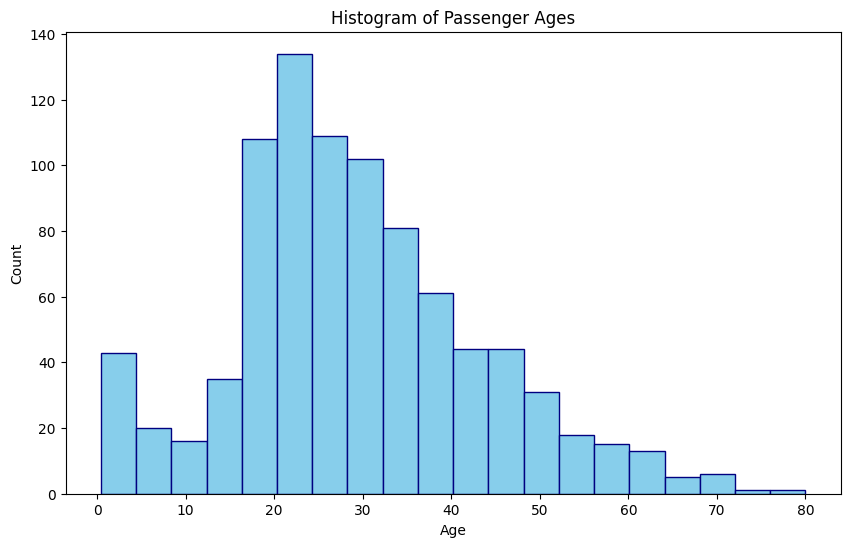

In [69]:
# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))#set plot size
plt.hist(titanic_df['Age'], bins=20, color='skyblue', edgecolor='navy')#create plot
#Add title and label of axis
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()#display plot

# **Summary and Insights:**

*   Most passengers were between 20 and 40 years old, with a peak around 20–25 years.
*   Very few passengers were children (<10 years) or elderly (>60 years).

*   Age distribution is right-skewed, with a long tail toward older ages.

Age is likely an important feature for survival analysis, especially for younger passengers (children) who may have higher survival rates.


/tmp/ipykernel_3141/3454315025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=survival_rates, palette='Set1') # Create barplot with a color palette


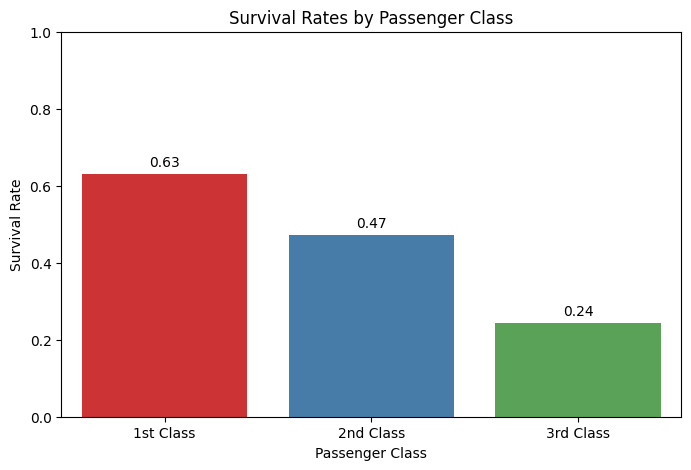

In [70]:
# TODO: Create a bar plot of survival rates by passenger class
survival_rates=titanic_df.groupby('Pclass')['Survived'].mean().reset_index() # Calculate survival rates by passenger class

plt.figure(figsize=(8, 5))#set plot size
sns.barplot(x='Pclass', y='Survived', data=survival_rates, palette='Set1') # Create barplot with a color palette
#Add title and label of axis
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class']) # Correct way to set custom labels for Pclass
plt.ylim(0, 1) # Survival rate is between 0 and 1

# Add labels to each bar
for index, row in survival_rates.iterrows():
    plt.text(index, row['Survived'] + 0.02, f"{row['Survived']:.2f}", color='black', ha="center")

plt.show()#display plot

# **Summary and Insights:**

*   1st Class shows ~63% survival passengers.
*   2nd Class shows ~47% survival passengers.
*   3rd Class shows ~24% survival passengers.

Survival rate decreases with lower passenger class. Class strongly influences survival probability as wealthier passengers (1st class) had better access to lifeboats.

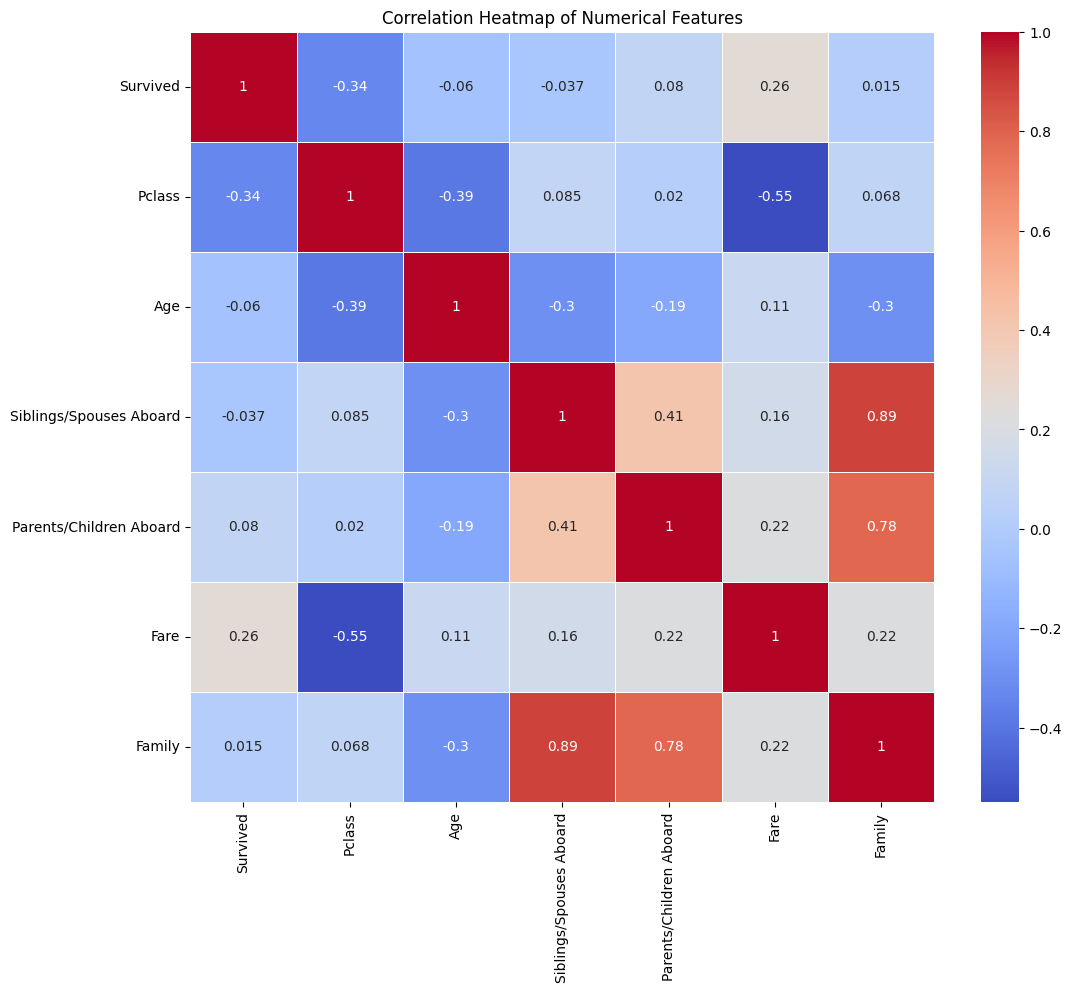

In [71]:
# TODO: Create a heatmap of correlation between numerical features
plt.figure(figsize=(12, 10))#set plot size
titanic_df_corr = titanic_df.corr(numeric_only=True)#calculate correlation value for numerical columns
sns.heatmap(titanic_df_corr, annot=True, cmap='coolwarm', linewidths=0.5)#create heatmap
plt.title('Correlation Heatmap of Numerical Features')#add title
plt.show()#display plot

# **Summary and Insights:**

**Correlation with Survived:**
*   Pclass (-0.34) means moderate negative correlation shows passengers in higher classes (lower Pclass number) had higher survival rates.
*   Fare (0.26) means weak positive correlation shows higher-paying passengers were more likely to survive.
*   Age (-0.06) means very weak negative correlation shows age alone is not strongly correlated with survival.
*   Siblings/Spouses (-0.037), Parents/Children (0.08), Family (0.015) means very weak correlation shows family size has little direct impact on survival.

Here,Survival is mostly influenced by class and fare and less by age or family.

**Correlations among features:**

*  Pclass & Fare (-0.55) means Strong negative correlation shows higher-class passengers paid higher fares.
*  Siblings/Spouses & Family (0.89) means very strong positive correlation shows family size is mostly made up of siblings/spouses aboard.
*  Parents/Children & Family (0.78) means Strong positive correlation shows similar logic, family size includes parents/children.
*  Age correlations as weakly negative with Pclass (-0.39) and family (-0.3), and suggesting younger passengers were more likely in lower classes or smaller family groups.

Here,Family, Siblings/Spouses and Parents/Children are highly collinear, so including all three in a model may be redundant.Pclass and Fare are also correlated and careful feature selection may help avoid multicollinearity.

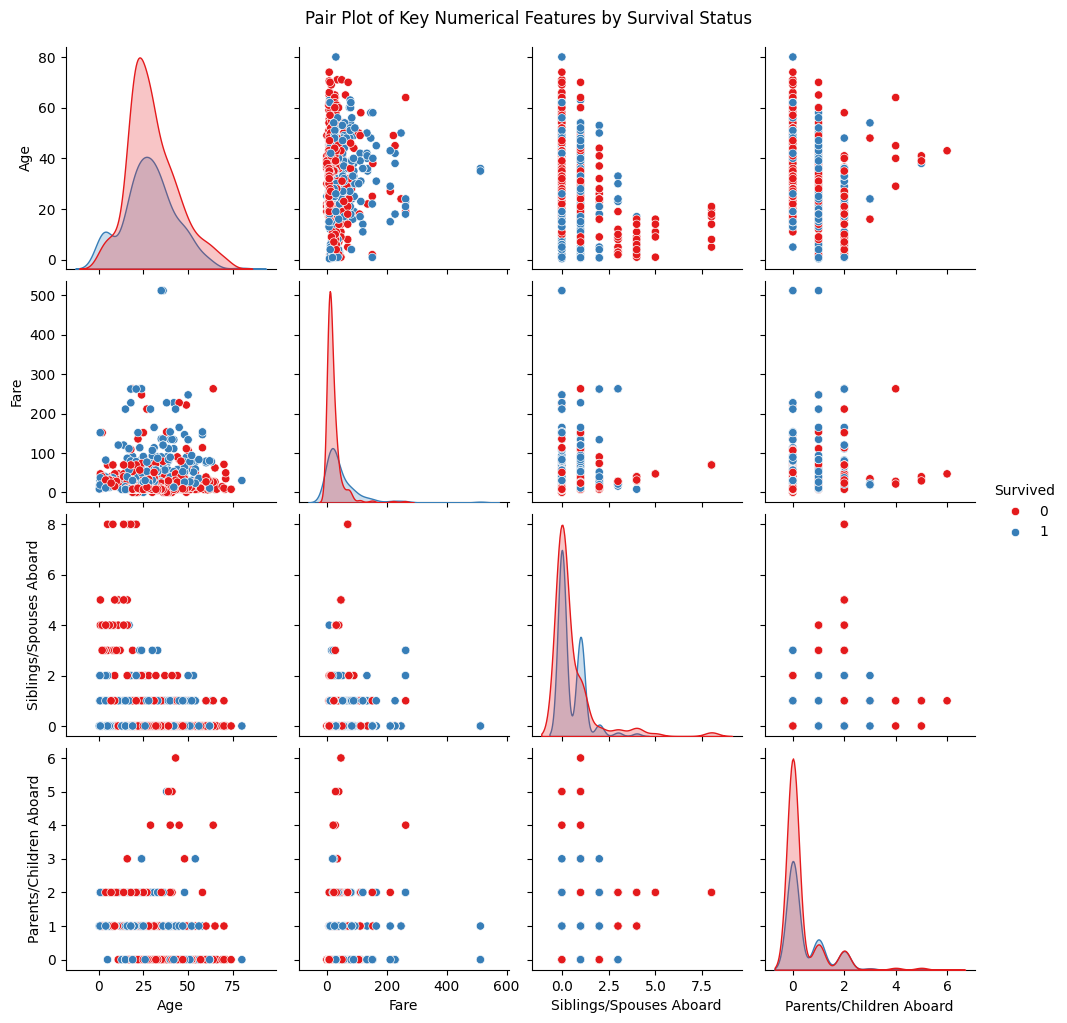

In [72]:
# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
sns.pairplot(titanic_df, vars=['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard'], hue='Survived', palette='Set1')
plt.suptitle('Pair Plot of Key Numerical Features by Survival Status', y=1.02)#add title
plt.show()#display plot


# **Summary and Insights:**

The pair plot reveals several clear patterns related to survival.
*   Passengers who survived tend to be younger, with a noticeable concentration of children among survivors, suggesting that younger individuals had a higher chance of survival.
*   Fare shows one of the strongest relationships with survival as those who paid higher fares were significantly more likely to survive, indicating that socio-economic status or passenger class played a major role.
*   In terms of family structure, most passengers traveled with zero or one sibling/spouse or parent/child, and survival rates appear higher for individuals or those in small families (one to two members).
*   In contrast, larger families tend to have lower survival rates, possibly due to the difficulty of coordinating escape in groups.
*   Relationships between features such as age and fare or family size are relatively weak, but overall, the data suggests that higher social class, younger age and smaller family size were associated with better chances of survival.

In [73]:
# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
survival_by_sex = titanic_df.groupby('Sex')['Survived'].mean().round(2)
print("Survival Rates by Sex:\n",survival_by_sex)

# TODO: Calculate and display survival rates by passenger class
survival_by_class = titanic_df.groupby('Pclass')['Survived'].mean().round(2)
print("\nSurvival Rates by Passenger Class:\n",survival_by_class)

Survival Rates by Sex:
 Sex
female    0.74
male      0.19
Name: Survived, dtype: float64

Survival Rates by Passenger Class:
 Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64


# **Summary and Insights:**
The survival rates show a clear difference based on both gender and passenger class. Females had a much higher survival rate (74%) compared to males (19%), indicating a strong advantage for women. Similarly, passengers in higher classes were more likely to survive, with first class having the highest survival rate (63%), followed by second class (47%) and third class with the lowest (24%). This highlights the significant impact of gender and socioeconomic status on survival outcomes.

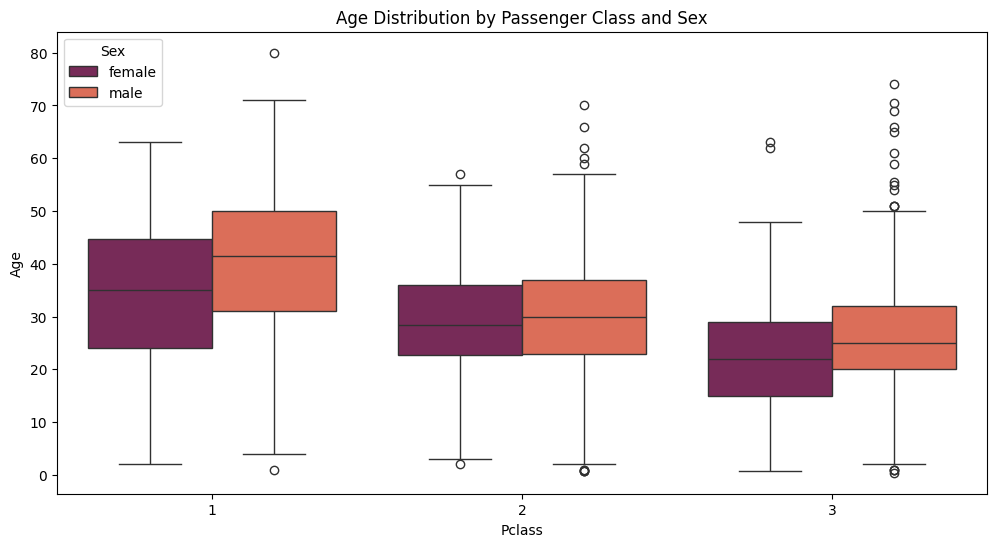

In [74]:
# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))#set plot size
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_df, palette='rocket')#create boxplot
plt.title('Age Distribution by Passenger Class and Sex')#add title
plt.show()#display plot

# **Summary and Insights:**

*  Females generally younger in 1st and 2nd class, with ages around 20 to 40.
*  Males in 1st class tend to be older, median around 40 to 45.
*  3rd class passengers skew younger overall, more variability among males.
*  Outliers as very old or very young exist in each class, more prominent in 1st and 3rd class.

Age distribution differs by sex and class. It could explain survival trends as  females and children had higher survival chances like "women and children first" policy.

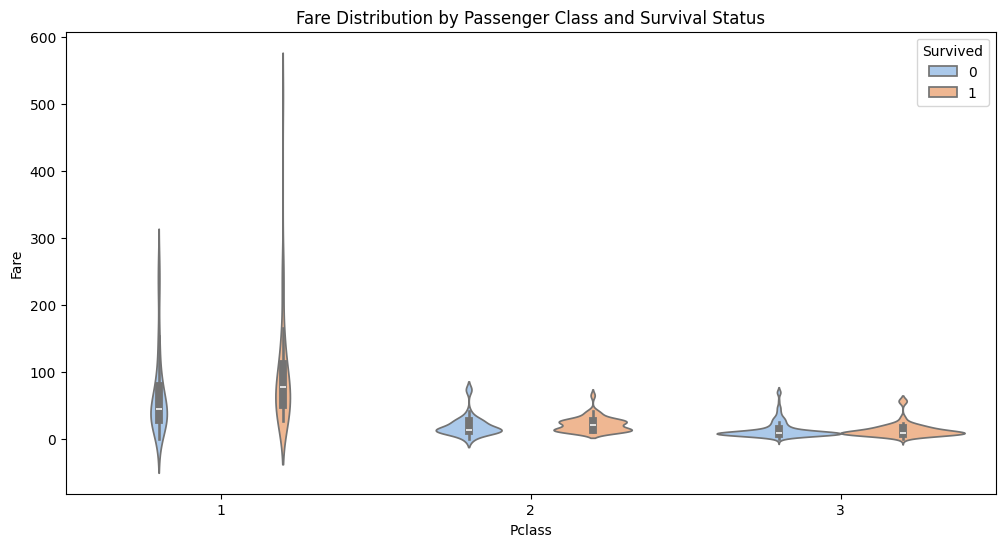

In [75]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))#set plot size
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=titanic_df, palette='pastel')#create violinplot
plt.title('Fare Distribution by Passenger Class and Survival Status')#add title
plt.show()#display plot

# **Summary and Insights:**

*   1st Class: Most fares are high; survivors paid higher fares than non-survivors.
*   2nd Class: Fare distribution narrower; survivors slightly higher fares than non-survivors.
*   3rd Class: Low fares overall; survival less correlated with fare.

Fare and class are correlated, and higher-paying passengers had a higher chance of survival, especially in 1st class.

In [76]:
print("EDA tasks completed.")

EDA tasks completed.
